# BTC — Bootstrap & Position Sizing

Vervolg op de robuustheidstest. Twee vragen:
1. **Hoe betrouwbaar is die Sharpe ~1 met maar 42 trades?** Bootstrap geeft een 95%-betrouwbaarheidsinterval i.p.v. één puntschatting.
2. **Hoeveel kun je de drawdown indammen zonder de edge te slopen?** We vergelijken all-in, vaste fractie, en volatility-targeting.

Fees 0,2% + slippage 0,1% zitten overal in. Zet `btc_1d.csv` in dezelfde map en draai van boven naar beneden.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)   # reproduceerbaar

CSV_PATH  = 'btc_1d.csv'
BASE_TEMA = 100
BASE_ATR  = 3.5
BASE_CMO  = 10
FEE       = 0.002
SLIP      = 0.001
START_CAP = 1000.0

# ---------- Indicatoren ----------
def tema(s, n):
    e1 = s.ewm(span=n, adjust=False).mean()
    e2 = e1.ewm(span=n, adjust=False).mean()
    e3 = e2.ewm(span=n, adjust=False).mean()
    return 3*(e1-e2)+e3

def cmo(s, w):
    d = s.diff()
    up = d.clip(lower=0).rolling(w).sum()
    dn = (-d.clip(upper=0)).rolling(w).sum()
    return 100*(up-dn)/(up+dn)

def atr(df, w=14):
    hl = df['high']-df['low']
    hc = (df['high']-df['close'].shift(1)).abs()
    lc = (df['low']-df['close'].shift(1)).abs()
    return pd.concat([hl,hc,lc],axis=1).max(axis=1).rolling(w).mean()

def prepare(path, tema_len=BASE_TEMA, vol_win=30):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['timestamp']).dt.date
    df = df.sort_values('date').reset_index(drop=True)
    df['TEMA'] = tema(df['close'], tema_len)
    df['CMO']  = cmo(df['close'], 14)
    df['ATR']  = atr(df, 14)
    df['VOL']  = df['close'].pct_change().rolling(vol_win).std()  # dagelijkse vol
    return df.dropna().reset_index(drop=True)

print('Indicatoren geladen.')

Indicatoren geladen.


In [2]:
# ---------- Backtest met sizing-modes ----------
# size_mode: 'full' (all-in), 'fixed' (vaste fractie), 'voltarget' (vol-targeting)
def backtest(df, cmo_trigger=BASE_CMO, atr_mult=BASE_ATR, fee=FEE, slip=SLIP,
             start_capital=START_CAP, size_mode='full', frac=1.0,
             target_vol=0.50, f_min=0.10, f_max=1.0):
    close=df['close'].values; tm=df['TEMA'].values; cm=df['CMO'].values
    at=df['ATR'].values; vol=df['VOL'].values
    cash, units = start_capital, 0.0
    in_pos, stop, peak = False, 0.0, 0.0
    entry_eq=None
    equity=np.empty(len(df)); trades=[]
    for i in range(len(df)):
        p,t,c,a = close[i],tm[i],cm[i],at[i]
        equity[i]=cash+units*p
        if in_pos and p<=stop:
            fill=p*(1-slip)
            cash+=units*fill*(1-fee)
            trades.append((entry_eq, cash))
            units,in_pos=0.0,False
            continue
        if in_pos:
            if p>peak: peak=p
            cand=peak-atr_mult*a
            if cand>stop: stop=cand
        if (not in_pos) and (p>t) and (c>cmo_trigger):
            entry_eq=cash+units*p
            if size_mode=='full':   f=1.0
            elif size_mode=='fixed': f=frac
            else:
                vann=vol[i]*np.sqrt(365)
                f=np.clip(target_vol/vann, f_min, f_max) if vann>0 else f_max
            invest=cash*f
            units=invest*(1-fee)/p
            cash=cash-invest
            in_pos=True; peak=p; stop=p-atr_mult*a
    final=cash+units*close[-1]
    # open positie aan einde marked-to-market als laatste trade
    if in_pos and entry_eq is not None:
        trades.append((entry_eq, final))
    eq=pd.Series(equity)
    rets=eq.pct_change().dropna()
    dd=(eq-eq.cummax())/eq.cummax()
    mdd=dd.min(); years=len(df)/365.0
    cagr=(final/start_capital)**(1/years)-1 if (years>0 and final>0) else -1.0
    sharpe=rets.mean()/rets.std()*np.sqrt(365) if rets.std()>0 else 0.0
    ds=rets[rets<0].std()
    sortino=rets.mean()/ds*np.sqrt(365) if (ds and ds>0) else 0.0
    calmar=cagr/abs(mdd) if mdd<0 else 0.0
    mult=[x/e for e,x in trades if e>0]
    wins=sum(1 for m in mult if m>1); n=len(mult)
    return dict(final=final,cagr=cagr,sharpe=sharpe,sortino=sortino,mdd=mdd,
                calmar=calmar,trades=n,win=(wins/n if n else 0),
                equity=eq,daily_returns=rets,trade_mult=np.array(mult),years=years)

df_full=prepare(CSV_PATH)
base=backtest(df_full, size_mode='full')
print(f"Baseline all-in: \u20ac{base['final']:,.0f} | CAGR {base['cagr']*100:.1f}% | "
      f"Sharpe {base['sharpe']:.2f} | Calmar {base['calmar']:.2f} | "
      f"MDD {base['mdd']*100:.1f}% | Trades {base['trades']} | Win {base['win']*100:.0f}%")
print(f"Per-trade multiples (eerste 5): {np.round(base['trade_mult'][:5],3)}")
print(f"Periode: {base['years']:.1f} jaar, {len(base['daily_returns'])} handelsdagen")

Baseline all-in: €21,499 | CAGR 44.6% | Sharpe 1.02 | Calmar 0.83 | MDD -53.8% | Trades 42 | Win 48%
Per-trade multiples (eerste 5): [0.859 1.01  1.055 0.952 0.932]
Periode: 8.3 jaar, 3034 handelsdagen


## Deel 1 — Bootstrap: hoe betrouwbaar zijn de cijfers?

**1a. Trade-bootstrap.** We trekken 42 trades mét teruglegging uit je werkelijke trades, 10.000 keer, en compounden ze. Dit beantwoordt: *had je geluk met wélke trades je kreeg?* Geeft een verdeling van eindkapitaal, CAGR en win%.

> Let op: de drawdown uit deze trade-bootstrap is op trade-niveau en **onderschat** de echte drawdown (intra-trade dalingen tellen niet mee). Voor realistische drawdown: zie 1b.

=== TRADE-BOOTSTRAP (10.000 herschikkingen van je 42 trades) ===
Eindkapitaal €   5%:       947  25%:     4,973  50%:    19,099  75%:    79,048  95%:   853,749
CAGR %           5%:      -0.6  25%:      21.3  50%:      42.6  75%:      69.1  95%:     125.2
Win %            5%:        36  25%:        43  50%:        48  75%:        52  95%:        60

Kans op verlies (eind < start): 5.3%
Kans dat je B&H (€5.672) verslaat: 72.6%


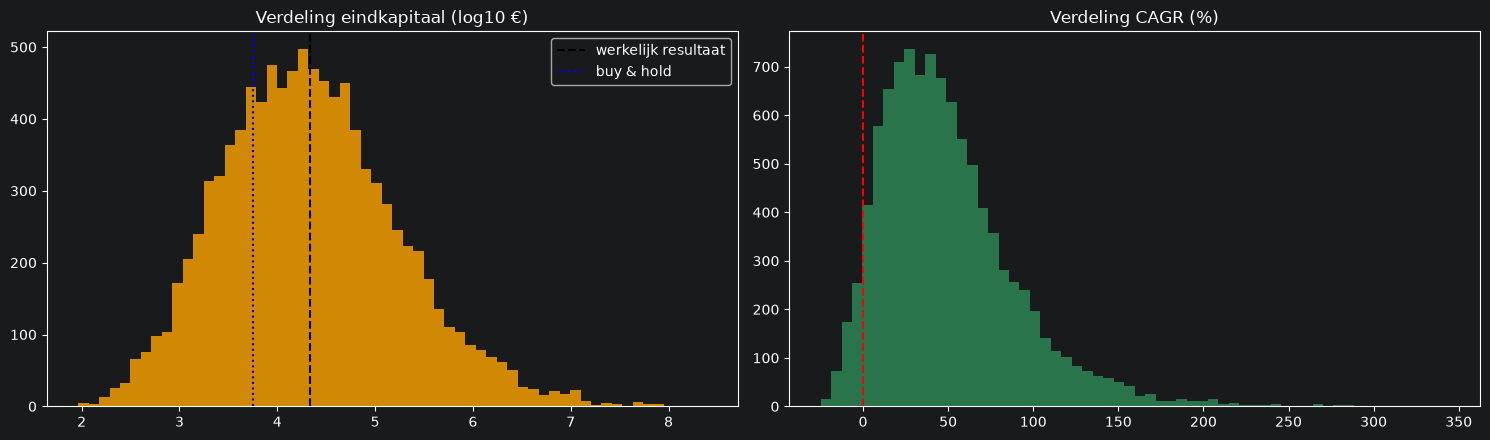

In [3]:
def trade_bootstrap(mult, years, n_iter=10000, start_cap=START_CAP):
    n=len(mult)
    fin=np.empty(n_iter); cagr=np.empty(n_iter); mdd=np.empty(n_iter); win=np.empty(n_iter)
    for k in range(n_iter):
        s=np.random.choice(mult, size=n, replace=True)
        eq=start_cap*np.cumprod(s)
        fin[k]=eq[-1]
        cagr[k]=(eq[-1]/start_cap)**(1/years)-1 if eq[-1]>0 else -1
        peak=np.maximum.accumulate(eq)
        mdd[k]=((eq-peak)/peak).min()
        win[k]=(s>1).mean()
    return fin,cagr,mdd,win

fin,cagr,mdd_t,win=trade_bootstrap(base['trade_mult'], base['years'])

def pct_table(name, arr, fmt='{:.2f}', scale=1.0):
    ps=np.percentile(arr*scale,[5,25,50,75,95])
    print(f"{name:<16} 5%:{fmt.format(ps[0]):>10}  25%:{fmt.format(ps[1]):>10}  "
          f"50%:{fmt.format(ps[2]):>10}  75%:{fmt.format(ps[3]):>10}  95%:{fmt.format(ps[4]):>10}")

print('=== TRADE-BOOTSTRAP (10.000 herschikkingen van je 42 trades) ===')
pct_table('Eindkapitaal \u20ac', fin, '{:,.0f}')
pct_table('CAGR %', cagr, '{:.1f}', 100)
pct_table('Win %', win, '{:.0f}', 100)
print(f"\nKans op verlies (eind < start): {(fin<START_CAP).mean()*100:.1f}%")
print(f"Kans dat je B&H (\u20ac5.672) verslaat: {(fin>5672).mean()*100:.1f}%")

fig,ax=plt.subplots(1,2,figsize=(15,4.5))
ax[0].hist(np.log10(fin),bins=60,color='orange',alpha=0.8)
ax[0].axvline(np.log10(base['final']),color='black',ls='--',label='werkelijk resultaat')
ax[0].axvline(np.log10(5672),color='blue',ls=':',label='buy & hold')
ax[0].set_title('Verdeling eindkapitaal (log10 \u20ac)'); ax[0].legend()
ax[1].hist(cagr*100,bins=60,color='seagreen',alpha=0.8)
ax[1].axvline(0,color='red',ls='--'); ax[1].set_title('Verdeling CAGR (%)')
plt.tight_layout(); plt.show()

**1b. Daily block-bootstrap.** Voor Sharpe en een eerlijke drawdown resamplen we *blokken* van 20 opeenvolgende dag-returns (zo blijft autocorrelatie deels behouden), bouwen een nieuwe equity-curve, 2.000 keer. Dit beantwoordt: *hoe stabiel is de Sharpe, en hoe diep kan de drawdown realistisch worden?*

=== DAILY BLOCK-BOOTSTRAP (2.000 paden, blokken van 20 dagen) ===
Sharpe           5%:      0.41  25%:      0.79  50%:      1.02  75%:      1.27  95%:      1.63
Max Drawdown %   5%:     -78.4  25%:     -65.0  50%:     -56.1  75%:     -49.1  95%:     -40.6

Kans Sharpe > 0.5: 91.7%
Kans Sharpe > 1.0: 53.0%
5%-slechtste drawdown: -78.4%  <- hierop moet je je mentaal voorbereiden


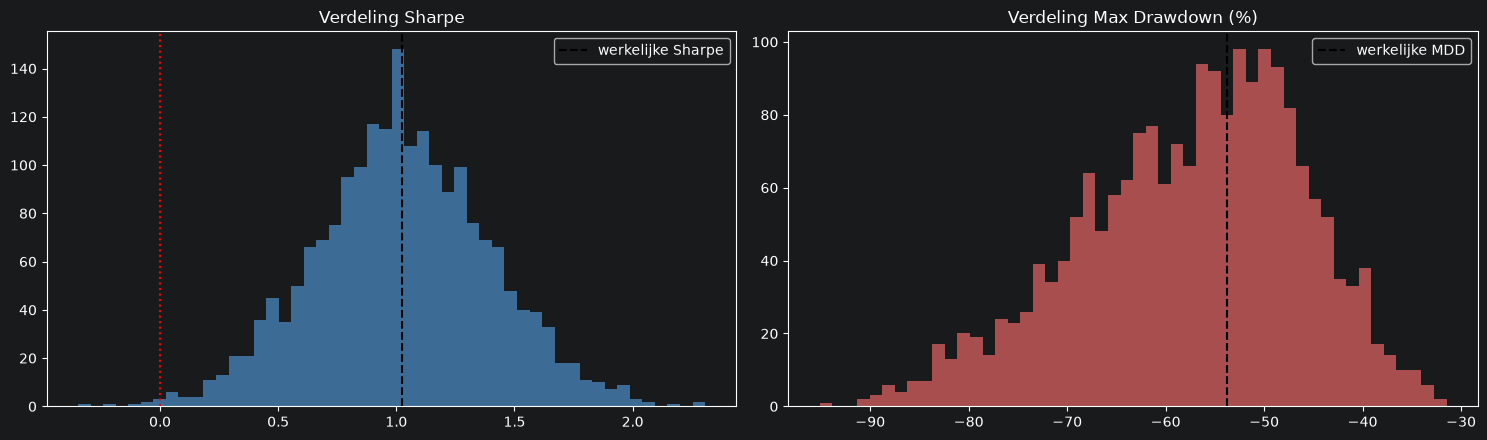

In [4]:
def block_bootstrap_daily(returns, n_iter=2000, block=20, periods=365):
    r=returns.values; T=len(r); nb=int(np.ceil(T/block))
    sh=np.empty(n_iter); md=np.empty(n_iter)
    for k in range(n_iter):
        starts=np.random.randint(0,T-block+1,size=nb)
        idx=(starts[:,None]+np.arange(block)[None,:]).ravel()[:T]
        rr=r[idx]; sd=rr.std()
        sh[k]=rr.mean()/sd*np.sqrt(periods) if sd>0 else 0
        eq=np.cumprod(1+rr); peak=np.maximum.accumulate(eq)
        md[k]=((eq-peak)/peak).min()
    return sh,md

sh,md=block_bootstrap_daily(base['daily_returns'])
print('=== DAILY BLOCK-BOOTSTRAP (2.000 paden, blokken van 20 dagen) ===')
pct_table('Sharpe', sh, '{:.2f}')
pct_table('Max Drawdown %', md, '{:.1f}', 100)
print(f"\nKans Sharpe > 0.5: {(sh>0.5).mean()*100:.1f}%")
print(f"Kans Sharpe > 1.0: {(sh>1.0).mean()*100:.1f}%")
print(f"5%-slechtste drawdown: {np.percentile(md,5)*100:.1f}%  <- hierop moet je je mentaal voorbereiden")

fig,ax=plt.subplots(1,2,figsize=(15,4.5))
ax[0].hist(sh,bins=50,color='steelblue',alpha=0.8)
ax[0].axvline(base['sharpe'],color='black',ls='--',label='werkelijke Sharpe')
ax[0].axvline(0,color='red',ls=':'); ax[0].set_title('Verdeling Sharpe'); ax[0].legend()
ax[1].hist(md*100,bins=50,color='indianred',alpha=0.8)
ax[1].axvline(base['mdd']*100,color='black',ls='--',label='werkelijke MDD')
ax[1].set_title('Verdeling Max Drawdown (%)'); ax[1].legend()
plt.tight_layout(); plt.show()

## Deel 2 — Position sizing: drawdown temmen

**2a. Vaste fractie.** Elke trade investeer je een vast percentage van je equity, de rest blijft cash. Belangrijke les vooraf: dit verlaagt je drawdown én je rendement ongeveer evenredig — je **Sharpe blijft vrijwel gelijk**. Het is geen gratis lunch; het is kiezen welk absoluut risiconiveau je kunt uitzitten.

 frac  cagr    mdd  sharpe  calmar    final
  0.2 13.43 -17.73    1.01    0.76  2851.69
  0.3 18.91 -24.19    1.03    0.78  4221.98
  0.4 23.82 -29.77    1.04    0.80  5908.36
  0.5 28.24 -34.72    1.04    0.81  7908.70
  0.6 32.23 -39.18    1.04    0.82 10205.77
  0.7 35.84 -43.26    1.04    0.83 12766.98
  0.8 39.09 -47.03    1.04    0.83 15545.08
  0.9 42.02 -50.53    1.03    0.83 18479.66
  1.0 44.62 -53.80    1.02    0.83 21499.42


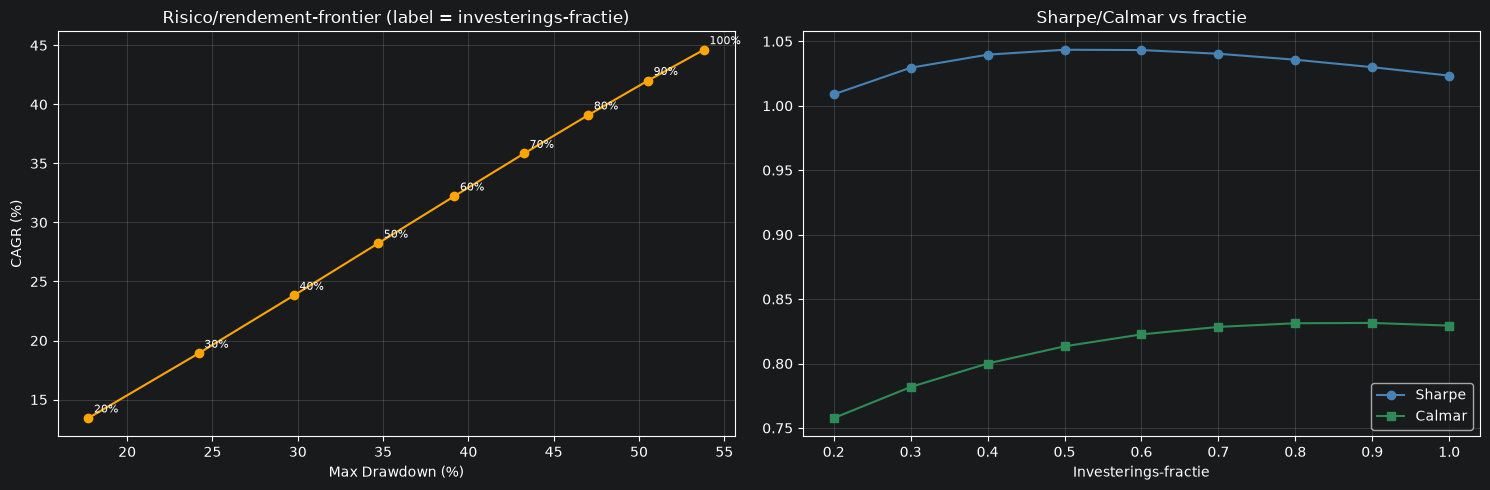


Merk op: Sharpe blijft vrijwel vlak -> vaste fractie schuift je langs dezelfde lijn.


In [5]:
fracs=[0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
rows=[]
for f in fracs:
    r=backtest(df_full, size_mode='fixed', frac=f)
    rows.append({'frac':f,'cagr':r['cagr']*100,'mdd':r['mdd']*100,
                 'sharpe':r['sharpe'],'calmar':r['calmar'],'final':r['final']})
fs=pd.DataFrame(rows)
print(fs.round(2).to_string(index=False))

fig,ax=plt.subplots(1,2,figsize=(15,5))
ax[0].plot(-fs['mdd'],fs['cagr'],'o-',color='orange')
for _,row in fs.iterrows():
    ax[0].annotate(f"{row['frac']:.0%}",(-row['mdd'],row['cagr']),fontsize=8,
                   xytext=(4,4),textcoords='offset points')
ax[0].set_xlabel('Max Drawdown (%)'); ax[0].set_ylabel('CAGR (%)')
ax[0].set_title('Risico/rendement-frontier (label = investerings-fractie)'); ax[0].grid(alpha=0.3)
ax[1].plot(fs['frac'],fs['sharpe'],'o-',label='Sharpe',color='steelblue')
ax[1].plot(fs['frac'],fs['calmar'],'s-',label='Calmar',color='seagreen')
ax[1].set_xlabel('Investerings-fractie'); ax[1].set_title('Sharpe/Calmar vs fractie')
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('\nMerk op: Sharpe blijft vrijwel vlak -> vaste fractie schuift je langs dezelfde lijn.')

**2b. Volatility targeting.** Hier schalen we de positie *omgekeerd* met de recente volatiliteit: in rustige periodes meer exposure, in wilde periodes minder. Omdat je exposure terugneemt precies wanneer het risico hoog is, kan dit de Sharpe/Calmar daadwerkelijk verbeteren — het buigt de curve, in plaats van er langs te schuiven. (Fractie wordt bij entry gezet en vastgehouden tijdens de trade; geen hefboom, max 100%.)

=== VERGELIJKING ===
All-in (100%)                CAGR  44.6% | Sharpe 1.02 | Calmar 0.83 | MDD  -53.8% | €21,499
Vaste fractie 50%            CAGR  28.2% | Sharpe 1.04 | Calmar 0.81 | MDD  -34.7% | €7,909
Vol-target 40%               CAGR  48.4% | Sharpe 1.28 | Calmar 1.30 | MDD  -37.2% | €26,622
Vol-target 50%               CAGR  50.4% | Sharpe 1.24 | Calmar 1.19 | MDD  -42.2% | €29,702
Vol-target 60%               CAGR  48.2% | Sharpe 1.17 | Calmar 1.07 | MDD  -45.0% | €26,352


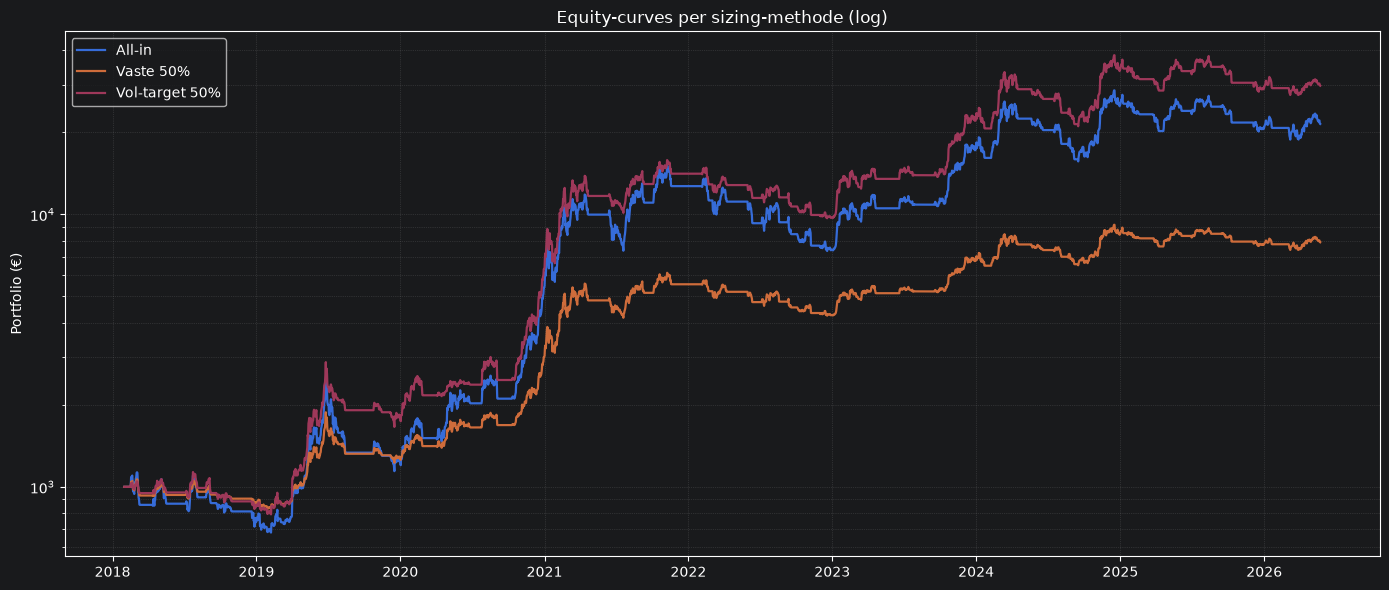

In [6]:
print('=== VERGELIJKING ===')
def line(name,r):
    print(f"{name:<28} CAGR {r['cagr']*100:5.1f}% | Sharpe {r['sharpe']:.2f} | "
          f"Calmar {r['calmar']:.2f} | MDD {r['mdd']*100:6.1f}% | \u20ac{r['final']:,.0f}")
line('All-in (100%)', backtest(df_full,size_mode='full'))
line('Vaste fractie 50%', backtest(df_full,size_mode='fixed',frac=0.5))
for tv in [0.40,0.50,0.60]:
    line(f'Vol-target {tv:.0%}', backtest(df_full,size_mode='voltarget',target_vol=tv))

# equity-curves vergelijken
fig,ax=plt.subplots(figsize=(14,6))
for label,r in [('All-in',backtest(df_full,size_mode='full')),
                ('Vaste 50%',backtest(df_full,size_mode='fixed',frac=0.5)),
                ('Vol-target 50%',backtest(df_full,size_mode='voltarget',target_vol=0.5))]:
    ax.plot(df_full['date'],r['equity'],lw=1.6,label=label)
ax.set_yscale('log'); ax.set_title('Equity-curves per sizing-methode (log)')
ax.set_ylabel('Portfolio (\u20ac)'); ax.legend(); ax.grid(alpha=0.3,which='both',ls=':')
plt.tight_layout(); plt.show()

## Hoe lees je dit

**Bootstrap (deel 1):**
- Trade-bootstrap: als de **5%-CAGR boven 0** ligt en de kans op verlies laag is, is je positieve resultaat geen toeval. Een brede verdeling betekent dat 42 trades simpelweg weinig zekerheid geeft — dat is geen fout, het is eerlijkheid over je sample.
- Daily-bootstrap: kijk naar de **5%-Sharpe** (is die nog boven 0?) en vooral de **5%-slechtste drawdown**. Dat laatste getal is wat je realistisch moet kunnen uitzitten — reken op dieper dan de -54% uit één enkele historische run.

**Position sizing (deel 2):**
- Vaste fractie: bevestigt je intuïtie (meer bescherming = minder PnL), Sharpe vlak. Kies de fractie waarbij de drawdown-kolom een getal toont dat je 's nachts laat slapen.
- Vol-targeting: als Calmar hier **hoger** is dan all-in bij een lagere drawdown, heb je een echte verbetering te pakken — niet alleen minder risico, maar beter risico-gecorrigeerd.

**Eerlijke grenzen van deze analyse:** de bootstrap neemt aan dat trades onderling uitwisselbaar zijn; bij sterke regime-afhankelijkheid onderschat dat het staartrisico. Vol-targeting gaat ervan uit dat volatiliteit enigszins voorspelbaar is (in crypto klopt dat redelijk, niet perfect). En alles blijft een backtest — de enige echte test is forward paper-trading op nieuwe data voordat er geld in gaat.

=== VOL-TARGET SWEEP ===
  target     CAGR   Sharpe   Calmar      MDD      Final
     20%    31.0%     1.24     1.28   -24.1% €    9,421
     30%    41.9%     1.29     1.34   -31.3% €   18,389
     40%    48.4%     1.28     1.30   -37.2% €   26,622
     50%    50.4%     1.24     1.19   -42.2% €   29,702
     60%    48.2%     1.17     1.07   -45.0% €   26,352
     70%    46.6%     1.11     0.96   -48.8% €   24,068
     80%    45.7%     1.08     0.89   -51.1% €   22,865
